In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_AIR = 1.0
scale = 0.58

curv = scale * np.array([83.6, 321.0, 44.8, -1150.0, 28.3, -38.5, 50.5, -53.2, 106.0, -120.0])
thick = scale * np.array([10.75, 15.55, 5.05, 5.05, 21.22, 13.9])
gaps = scale * np.array([1.65, 18.9, 0.97])
n_glass = [1.64238, 1.62306, 1.57566, 1.6727, 1.64238, 1.64238]

ratio = (thick.sum() + gaps.sum()) / 40.0
APERTURE_F_STOPS = np.array([2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0])
APERTURE_DIAMETERS_MM = np.array([3.0, 8.0, 12.0, 15.0, 17.2, 19.0, 20.0])
APERTURE_INDEX = len(APERTURE_DIAMETERS_MM) - 1  # widest setting for fully open aperture
APERTURE_RADIUS = 0.5 * APERTURE_DIAMETERS_MM[APERTURE_INDEX] * ratio

radii = 0.5 * np.array([41.5, 30.0, 20.0, 19.0, 25.0]) * ratio
LENS = list(zip(
    [0.0, curv[0], curv[1], curv[2], curv[3], curv[4], 0.0, curv[5], curv[6], curv[7], curv[8], curv[9]],
    [13.0 * ratio, thick[0], gaps[0], thick[1], thick[2], gaps[1] * 0.5, gaps[1] * 0.5, thick[3], thick[4], gaps[2], thick[5], 0.0],
    [N_AIR, n_glass[0], N_AIR, n_glass[1], n_glass[2], N_AIR, N_AIR, n_glass[3], n_glass[4], N_AIR, n_glass[5], N_AIR],
    [radii[0], radii[1], radii[1], radii[1], radii[1], radii[2], APERTURE_RADIUS, radii[3], radii[4], radii[4], radii[4], radii[4]]
))
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)

def refract(direction, normal, eta):
    cos_i = -np.dot(normal, direction)
    sin2_t = eta * eta * (1.0 - cos_i * cos_i)
    if sin2_t > 1.0:
        return None
    cos_t = np.sqrt(max(0.0, 1.0 - sin2_t))
    return eta * direction + (eta * cos_i - cos_t) * normal

def intersect_surface(origin, direction, curvature, z_surface):
    if abs(curvature) < 1e-9:
        if abs(direction[2]) < 1e-12:
            return None
        t = (z_surface - origin[2]) / direction[2]
        if t <= 0.0:
            return None
        hit = origin + t * direction
        normal = np.array([0.0, 0.0, 1.0])
        if np.dot(direction, normal) > 0.0:
            normal = -normal
        return hit, normal
    radius = abs(curvature)
    center = np.array([0.0, 0.0, z_surface + curvature])
    oc = origin - center
    a = np.dot(direction, direction)
    b = np.dot(oc, direction)
    c = np.dot(oc, oc) - radius * radius
    disc = b * b - a * c
    if disc < 0.0:
        return None
    sqrt_disc = np.sqrt(disc)
    t0 = (-b - sqrt_disc) / a
    t1 = (-b + sqrt_disc) / a
    if t0 > t1:
        t0, t1 = t1, t0
    use_first = (direction[2] > 0.0) ^ (curvature < 0.0)
    t = t0 if use_first else t1
    if t <= 0.0:
        return None
    hit = origin + t * direction
    normal = hit - center
    normal /= np.linalg.norm(normal)
    if np.dot(direction, normal) > 0.0:
        normal = -normal
    return hit, normal

def trace_ray(ray_origin, target_point, record_path=False):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return None
    direction /= norm_dir
    path = [origin.copy()] if record_path else None
    z_surface = 0.0
    n_current = N_AIR
    for curvature, thickness, n_next, aperture in LENS:
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return None
        hit, normal = result
        if aperture > 0.0 and hit[0] * hit[0] + hit[1] * hit[1] > aperture * aperture:
            return None
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return None
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        if record_path:
            path.append(origin.copy())
        n_current = n_next
        z_surface += thickness
    return {
        "position": origin,
        "direction": direction,
        "path": np.vstack(path) if record_path else None
    }

def trace_ray_verbose(ray_origin, target_point):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    path = [origin.copy()]
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "result": None,
            "path": np.vstack(path),
            "failure": "degenerate_direction",
            "failure_point": origin.copy()
        }
    direction /= norm_dir
    z_surface = 0.0
    n_current = N_AIR
    for curvature, thickness, n_next, aperture in LENS:
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "surface_miss",
                "failure_point": path[-1].copy()
            }
        hit, normal = result
        path.append(hit.copy())
        if aperture > 0.0 and hit[0] * hit[0] + hit[1] * hit[1] > aperture * aperture:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "aperture_clip",
                "failure_point": hit.copy()
            }
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "total_internal_reflection",
                "failure_point": hit.copy()
            }
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        n_current = n_next
        z_surface += thickness
    path_array = np.vstack(path)
    result = {
        "position": origin,
        "direction": direction,
        "path": path_array
    }
    return {
        "result": result,
        "path": path_array,
        "failure": None,
        "failure_point": None
    }

# Calculate focal distance to focal length conversion

In [2]:
def focus_from_two_rays(object_distance_mm, entry_scale=0.8, record_paths=False):
    origin = np.array([0.0, 0.0, -object_distance_mm], dtype=float)
    entry = entry_scale * APERTURE_RADIUS
    aims = (np.array([0.0, 0.0, 0.0]), np.array([entry, 0.0, 0.0]))
    rays = [trace_ray(origin, aim, record_paths) for aim in aims]
    if any(ray is None for ray in rays):
        return None
    p1, d1 = rays[0]["position"], rays[0]["direction"]
    p2, d2 = rays[1]["position"], rays[1]["direction"]
    a = np.dot(d1, d1)
    b = np.dot(d1, d2)
    c = np.dot(d2, d2)
    w0 = p1 - p2
    d = np.dot(d1, w0)
    e = np.dot(d2, w0)
    denom = a * c - b * b
    if abs(denom) < 1e-12:
        return None
    t1 = (b * e - c * d) / denom
    t2 = (a * e - b * d) / denom
    q1 = p1 + t1 * d1
    q2 = p2 + t2 * d2
    focus_point = 0.5 * (q1 + q2)
    result = {
        "point": focus_point,
        "residual_mm": np.linalg.norm(q1 - q2),
    }
    if record_paths:
        result["paths"] = [r["path"] for r in rays]
    return result

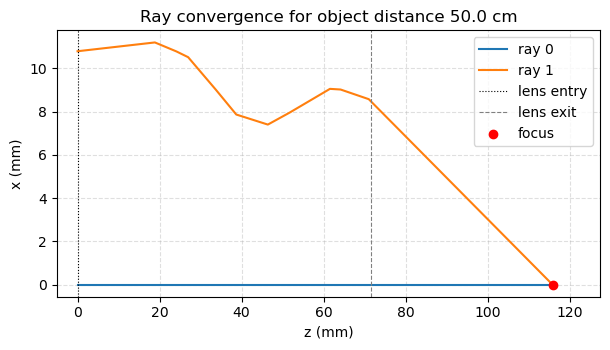

Object distance: 50.000 cm
Distance beyond lens exit: 44.254 mm
Ray intersection residual: 0.000 µm


In [3]:
object_distance_cm = 50.0
focus_info = focus_from_two_rays(object_distance_cm * 10.0, record_paths=True)

if focus_info is None:
    print("Ray tracing failed for the selected object distance.")
else:
    focus = focus_info["point"]
    residual_um = focus_info["residual_mm"] * 1e3

    plt.figure(figsize=(6.2, 3.6))
    for idx, path in enumerate(focus_info.get("paths", [])):
        segment = path[path[:, 2] >= -5.0]
        curve = np.vstack([segment, focus])
        plt.plot(curve[:, 2], curve[:, 0], label=f"ray {idx}")
    plt.axvline(0.0, color="black", linewidth=0.8, linestyle=":", label="lens entry")
    plt.axvline(LENS_LENGTH_MM, color="gray", linewidth=0.8, linestyle="--", label="lens exit")
    plt.scatter([focus[2]], [focus[0]], color="red", zorder=5, label="focus")
    plt.xlabel("z (mm)")
    plt.ylabel("x (mm)")
    plt.title(f"Ray convergence for object distance {object_distance_cm:.1f} cm")
    plt.xlim(-5.0, focus[2] * 1.1)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Object distance: {object_distance_cm:.3f} cm")
    print(f"Distance beyond lens exit: {focus[2] - LENS_LENGTH_MM:.3f} mm")
    print(f"Ray intersection residual: {residual_um:.3f} µm")

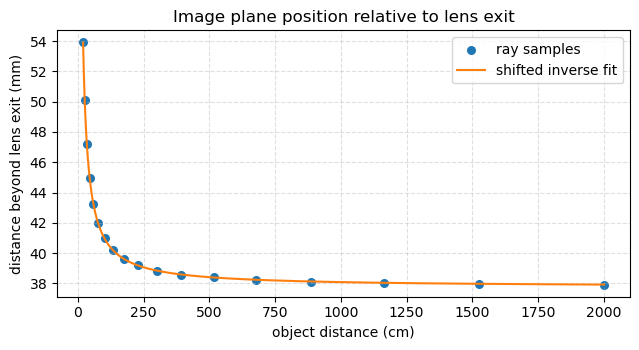

Rational function fit: f(x_cm) = a / (x_cm + b) + c
  a ≈ 325.949 mm·cm
  b ≈ 0.191 cm
  c ≈ 37.760 mm
  MSE ≈ 0.0000 mm^2


In [4]:
from scipy.optimize import curve_fit

object_distances_cm = np.geomspace(20.0, 2000.0, 18)
samples = []
for dist_cm in object_distances_cm:
    focus = focus_from_two_rays(dist_cm * 10.0)
    if focus is None or focus["residual_mm"] > 1e-3:
        continue
    samples.append((dist_cm, focus["point"][2] - LENS_LENGTH_MM))

if not samples:
    print("No focus samples collected.")
else:
    obj_cm, offset_mm = np.array(samples).T
    order = np.argsort(obj_cm)
    obj_cm = obj_cm[order]
    offset_mm = offset_mm[order]

    def rational_function_mm(x_cm, a, b, c):
        return a / (x_cm + b) + c

    popt, _ = curve_fit(rational_function_mm, obj_cm, offset_mm, p0=(5000.0, 0.0, 40.0), maxfev=20000)
    obj_fit = np.geomspace(obj_cm.min(), obj_cm.max(), 200)
    offset_fit = rational_function_mm(obj_fit, *popt)

    plt.figure(figsize=(6.5, 3.6))
    plt.scatter(obj_cm, offset_mm, s=30, label="ray samples")
    plt.plot(obj_fit, offset_fit, color="tab:orange", label="shifted inverse fit")
    plt.xlabel("object distance (cm)")
    plt.ylabel("distance beyond lens exit (mm)")
    plt.title("Image plane position relative to lens exit")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    mse = float(np.mean((rational_function_mm(obj_cm, *popt) - offset_mm) ** 2))
    a_fit, b_fit, c_fit = popt
    print("Rational function fit: f(x_cm) = a / (x_cm + b) + c")
    print(f"  a ≈ {a_fit:.3f} mm·cm")
    print(f"  b ≈ {b_fit:.3f} cm")
    print(f"  c ≈ {c_fit:.3f} mm")
    print(f"  MSE ≈ {mse:.4f} mm^2")

In [5]:
def object_distance_cm_to_focal_length_mm(object_distance_cm):
    a, b, c = popt
    image_distance_mm = rational_function_mm(object_distance_cm, a, b, c) + LENS_LENGTH_MM
    return 1.0 / (1.0 / (object_distance_cm * 10.0) + 1.0 / image_distance_mm)

# Distort noise through the camera lens

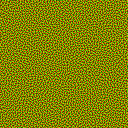

In [6]:
from PIL import Image
path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples500000_od500_lidx0of8_0.png"

noisemap = Image.open(path)
display(noisemap)

In [7]:
object_distance_cm = 10.0
focal_length_mm = object_distance_cm_to_focal_length_mm(object_distance_cm)

sample_count = 10000

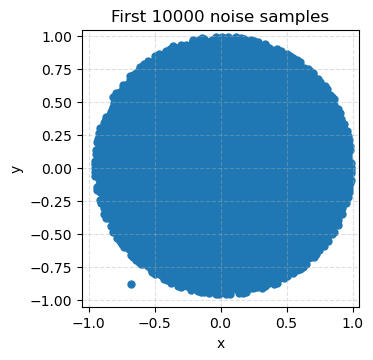

array([[ 0.32549024,  0.082353  ],
       [-0.56078434, -0.6784314 ],
       [-0.08235294,  0.45098042],
       ...,
       [-0.8901961 ,  0.24705887],
       [ 0.54509807, -0.67058825],
       [ 0.12941182,  0.8745098 ]], dtype=float32)

In [8]:
import numpy as np

# Map RGB channels from [0, 255] into [-1, 1] to interpret pixels as 2D positions.
pixel_data = np.asarray(noisemap, dtype=np.float32) / 255.0
flat_pixels = pixel_data.reshape(-1, pixel_data.shape[-1])
if flat_pixels.shape[1] < 2:
    raise ValueError("Noisemap must expose at least two channels for XY data.")
count = min(sample_count, flat_pixels.shape[0])
samples_xy = flat_pixels[:count, :2] * 2.0 - 1.0

fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.scatter(samples_xy[:, 0], samples_xy[:, 1], color="tab:blue", s=25)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"First {count} noise samples")
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

samples_xy

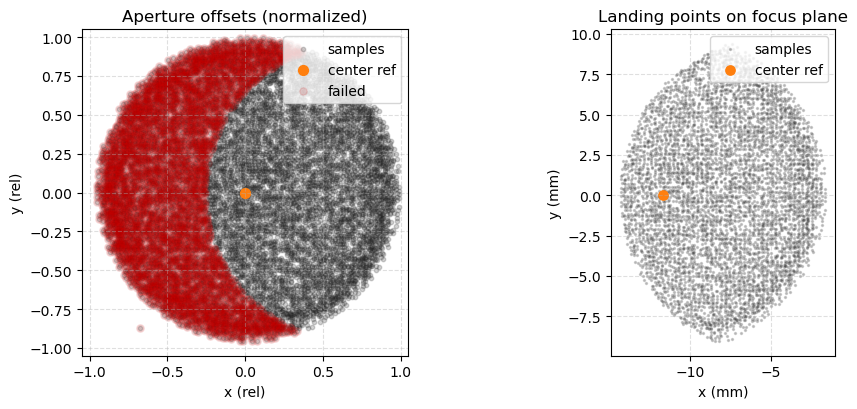

Failed rays: 1, 3, 4, 6, 11, 12, 14, 15, 16, 17, 22, 24, 26, 28, 30, 31, 34, 39, 41, 43, 44, 45, 47, 49, 50, 52, 53, 55, 56, 57, 58, 59, 61, 62, 65, 67, 70, 72, 73, 75, 76, 77, 78, 82, 83, 85, 88, 91, 98, 99, 101, 102, 103, 104, 106, 107, 108, 109, 113, 114, 115, 120, 121, 123, 124, 125, 129, 133, 134, 136, 137, 145, 147, 148, 149, 152, 158, 159, 161, 164, 165, 167, 168, 171, 175, 177, 182, 187, 193, 195, 196, 198, 208, 213, 214, 215, 218, 220, 221, 223, 224, 229, 232, 234, 239, 240, 242, 244, 245, 247, 251, 254, 255, 256, 258, 260, 265, 266, 267, 269, 270, 271, 274, 275, 277, 278, 280, 281, 282, 283, 285, 289, 291, 292, 298, 299, 300, 302, 303, 305, 307, 308, 310, 311, 312, 315, 316, 318, 320, 322, 325, 327, 328, 330, 331, 332, 333, 334, 336, 338, 340, 341, 344, 346, 347, 349, 350, 352, 353, 354, 357, 361, 364, 365, 366, 370, 371, 373, 374, 375, 377, 378, 379, 380, 385, 386, 387, 389, 390, 391, 394, 399, 401, 405, 409, 412, 413, 415, 417, 418, 420, 423, 424, 427, 429, 432, 435, 438, 4

C:\Users\ckobalt\AppData\Local\Temp\1\ipykernel_60644\3458004963.py:201: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


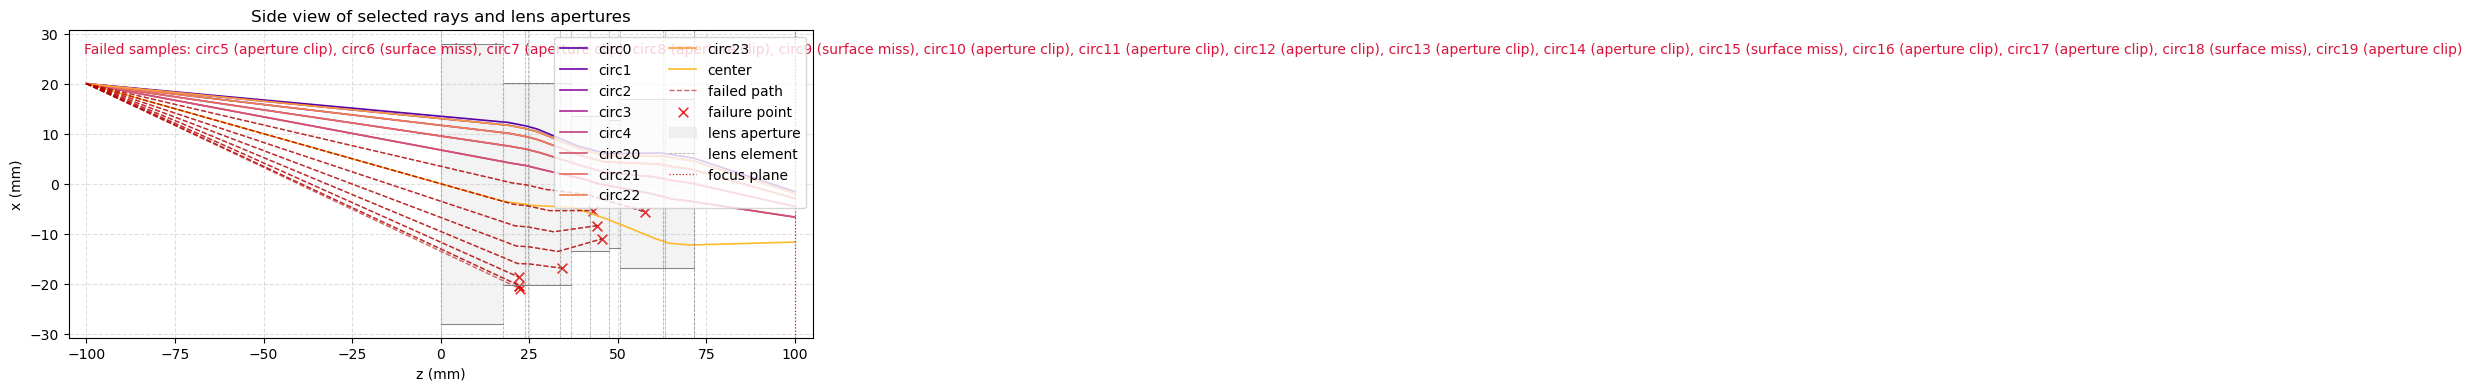

,sample,entry_x_rel,entry_y_rel,entry_x_mm,entry_y_mm,image_x_mm,image_y_mm,image_z_mm
0,0,0.325490,0.082353,4.391124,1.111008,-8.410304,0.825696,100.0
1,2,-0.082353,0.450980,-1.111007,6.084087,-12.587522,4.575656,100.0
2,5,0.600000,0.466667,8.094480,6.295707,-5.644248,4.693550,100.0
3,7,-0.066667,0.513726,-0.899387,6.930568,-12.451190,5.229791,100.0
4,8,0.678431,0.733333,9.152582,9.893254,-4.846019,7.414763,100.0
...,...,...,...,...,...,...,...,...
5468,9993,-0.160784,-0.341176,-2.169109,-4.602743,-13.397331,-3.467555,100.0
5469,9994,0.537255,0.152941,7.247999,2.063300,-6.282617,1.539285,100.0
5470,9996,-0.003922,0.105882,-0.052905,1.428438,-11.706973,1.059575,100.0
5471,9998,0.545098,-0.670588,7.353809,-9.046772,-6.198278,-6.756545,100.0


In [9]:
world_origin = np.array([20.0, 0.0, -object_distance_cm * 10.0], dtype=float)
focus_estimate = focus_from_two_rays(object_distance_cm * 10.0)
if focus_estimate is None:
    raise RuntimeError("Unable to determine focus plane for the given object distance.")
focus_plane_z = 100  # float(focus_estimate["point"][2])

entry_offsets = np.vstack([samples_xy, np.zeros((1, 2), dtype=samples_xy.dtype)])
entry_labels = [str(i) for i in range(samples_xy.shape[0])] + ["C"]
is_center = np.zeros(entry_offsets.shape[0], dtype=bool)
is_center[-1] = True
entry_points_xy_mm = entry_offsets * APERTURE_RADIUS
entry_points_mm = np.column_stack([entry_points_xy_mm, np.zeros(entry_offsets.shape[0])])

landing_points_xy = []
landing_is_center = []
landing_records = []
failed_samples = []
failed_offsets_rel = []
failed_is_center = []

def record_failure(idx):
    failed_samples.append(entry_labels[idx])
    failed_offsets_rel.append(entry_offsets[idx])
    failed_is_center.append(is_center[idx])

for idx, entry_point_mm in enumerate(entry_points_mm):
    ray = trace_ray(world_origin, entry_point_mm, record_path=False)
    if ray is None:
        record_failure(idx)
        continue
    last_pos = ray["position"]
    last_dir = ray["direction"]
    if abs(last_dir[2]) < 1e-9:
        record_failure(idx)
        continue
    travel = (focus_plane_z - last_pos[2]) / last_dir[2]
    if travel <= 0.0:
        record_failure(idx)
        continue
    landing_point = last_pos + travel * last_dir
    landing_points_xy.append(landing_point[:2])
    landing_is_center.append(is_center[idx])
    landing_records.append({
        "sample": "center" if is_center[idx] else int(entry_labels[idx]),
        "entry_x_rel": float(entry_offsets[idx, 0]),
        "entry_y_rel": float(entry_offsets[idx, 1]),
        "entry_x_mm": float(entry_points_xy_mm[idx, 0]),
        "entry_y_mm": float(entry_points_xy_mm[idx, 1]),
        "image_x_mm": float(landing_point[0]),
        "image_y_mm": float(landing_point[1]),
        "image_z_mm": float(landing_point[2])
    })

landing_xy_mm = np.asarray(landing_points_xy, dtype=float) if landing_points_xy else np.empty((0, 2))
landing_is_center = np.asarray(landing_is_center, dtype=bool) if landing_points_xy else np.zeros(0, dtype=bool)
failed_entry_offsets = np.asarray(failed_offsets_rel, dtype=float) if failed_offsets_rel else np.empty((0, 2))
failed_is_center = np.asarray(failed_is_center, dtype=bool) if failed_is_center else np.zeros(0, dtype=bool)

circle_count = 24
angles = np.linspace(0.0, 2.0 * np.pi, circle_count, endpoint=False)
circle_offsets = np.column_stack([np.cos(angles), np.sin(angles)])
sideview_offsets = np.vstack([circle_offsets, np.zeros((1, 2))])
sideview_is_center = np.zeros(sideview_offsets.shape[0], dtype=bool)
sideview_is_center[-1] = True
sideview_labels = [f"circ{i}" for i in range(circle_count)] + ["center"]
sideview_display = ["center" if flag else label for label, flag in zip(sideview_labels, sideview_is_center)]

sideview_successes = []
sideview_failures = []
for offset, is_ctr, display_label in zip(sideview_offsets, sideview_is_center, sideview_display):
    entry_point_mm = np.array([offset[0] * APERTURE_RADIUS, offset[1] * APERTURE_RADIUS, 0.0])
    ray_info = trace_ray_verbose(world_origin, entry_point_mm)
    if ray_info["result"] is None:
        reason = (ray_info["failure"] or "failed").replace("_", " ")
        sideview_failures.append({
            "label": display_label,
            "reason": reason,
            "path": ray_info["path"],
            "point": ray_info["failure_point"]
        })
        continue
    result = ray_info["result"]
    last_pos = result["position"]
    last_dir = result["direction"]
    if abs(last_dir[2]) < 1e-9:
        sideview_failures.append({
            "label": display_label,
            "reason": "tangent to focus",
            "path": result["path"],
            "point": result["path"][-1]
        })
        continue
    travel = (focus_plane_z - last_pos[2]) / last_dir[2]
    if travel <= 0.0:
        sideview_failures.append({
            "label": display_label,
            "reason": "focus plane behind",
            "path": result["path"],
            "point": result["path"][-1]
        })
        continue
    landing_point = last_pos + travel * last_dir
    sideview_successes.append({
        "label": display_label,
        "is_center": is_ctr,
        "path": np.vstack([result["path"], landing_point])
    })

sample_color = (0.12, 0.12, 0.12, 0.2)
failed_color = (0.8, 0.0, 0.0, 0.12)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
if (~is_center).any():
    axes[0].scatter(entry_offsets[~is_center, 0], entry_offsets[~is_center, 1], s=10, color=sample_color, label="samples")
axes[0].scatter(0.0, 0.0, s=50, color="tab:orange", label="center ref")
if failed_entry_offsets.size:
    non_center_fail = ~failed_is_center
    if non_center_fail.any():
        axes[0].scatter(failed_entry_offsets[non_center_fail, 0], failed_entry_offsets[non_center_fail, 1], s=28, color=failed_color, label="failed")
    if failed_is_center.any():
        axes[0].scatter(failed_entry_offsets[failed_is_center, 0], failed_entry_offsets[failed_is_center, 1], s=60, facecolor=failed_color, edgecolor="none", label="failed center")
axes[0].set_title("Aperture offsets (normalized)")
axes[0].set_xlabel("x (rel)")
axes[0].set_ylabel("y (rel)")
axes[0].set_xlim(-1.05, 1.05)
axes[0].set_ylim(-1.05, 1.05)
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend(loc="upper right")

if landing_xy_mm.size:
    sample_mask = ~landing_is_center
    if sample_mask.any():
        axes[1].scatter(landing_xy_mm[sample_mask, 0], landing_xy_mm[sample_mask, 1], s=2, color=sample_color, label="samples")
    if landing_is_center.any():
        axes[1].scatter(landing_xy_mm[landing_is_center, 0], landing_xy_mm[landing_is_center, 1], s=45, color="tab:orange", label="center ref")
else:
    axes[1].text(0.5, 0.5, "No rays reached focus plane", ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_title("Landing points on focus plane")
axes[1].set_xlabel("x (mm)")
axes[1].set_ylabel("y (mm)")
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

if failed_samples:
    print("Failed rays:", ", ".join(failed_samples))
else:
    print("All samples traced to the focus plane.")

if sideview_successes or sideview_failures:
    fig, ax = plt.subplots(figsize=(9.6, 4.0))
    colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(sideview_successes))) if sideview_successes else []
    for success, color in zip(sideview_successes, colors):
        ax.plot(success["path"][:, 2], success["path"][:, 0], color=color, linewidth=1.2, label=success["label"])

    failed_path_color = (0.7, 0.0, 0.0, 0.6)
    failed_point_color = (0.9, 0.0, 0.0, 0.85)
    for idx, failure in enumerate(sideview_failures):
        label_line = "failed path" if idx == 0 else None
        label_point = "failure point" if idx == 0 else None
        path = failure["path"]
        point = failure["point"]
        if path is not None and path.size:
            ax.plot(path[:, 2], path[:, 0], color=failed_path_color, linewidth=1.0, linestyle="--", label=label_line)
        if point is not None:
            ax.scatter(point[2], point[0], color=failed_point_color, s=48, marker="x", linewidths=1.1, label=label_point)

    surface_positions = np.cumsum([0.0] + [segment[1] for segment in LENS])
    lens_shade_label = None
    for idx, (segment, z_start, z_end) in enumerate(zip(LENS, surface_positions[:-1], surface_positions[1:])):
        aperture = segment[3]
        if aperture > 0.0:
            label = "lens aperture" if lens_shade_label is None else None
            ax.fill_between([z_start, z_end], [aperture, aperture], [-aperture, -aperture], color="lightgray", alpha=0.25, label=label)
            ax.plot([z_start, z_end], [aperture, aperture], color="gray", linewidth=0.7)
            ax.plot([z_start, z_end], [-aperture, -aperture], color="gray", linewidth=0.7)
            lens_shade_label = False
        ax.axvline(z_start, color="gray", linestyle="--", linewidth=0.6, alpha=0.6, label="lens element" if idx == 0 else None)
    ax.axvline(surface_positions[-1], color="gray", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.axvline(focus_plane_z, color="tab:red", linestyle=":", linewidth=0.9, label="focus plane")

    path_extents = []
    if sideview_successes:
        path_extents.extend(success["path"][:, 2].min() for success in sideview_successes)
    if sideview_failures:
        path_extents.extend(failure["path"][:, 2].min() for failure in sideview_failures if failure["path"] is not None and failure["path"].size)
    lim_low = min(path_extents) if path_extents else surface_positions[0]
    failure_descriptions = ", ".join(f"{f['label']} ({f['reason']})" for f in sideview_failures)
    if failure_descriptions:
        ax.text(0.02, 0.96, f"Failed samples: {failure_descriptions}", transform=ax.transAxes,
                fontsize=10, color="crimson", verticalalignment="top")
    ax.set_title("Side view of selected rays and lens apertures")
    ax.set_xlabel("z (mm)")
    ax.set_ylabel("x (mm)")
    ax.set_xlim(lim_low - 5.0, focus_plane_z * 1.05)
    ax.grid(True, linestyle="--", alpha=0.4)
    if sideview_successes or lens_shade_label is False or sideview_failures:
        ax.legend(loc="upper right", ncol=2)
    plt.tight_layout()
    plt.show()

import pandas as pd
landing_df = pd.DataFrame(landing_records)
display(landing_df)